# Geometric Transforms

In this example we demonstrate the operators from `transforms` module and how they can be used for transforming images and point clouds.

## Affine Transform

The operators from `transforms` module can generate and combine transform matrices for different kinds of affine transforms. An affine transform is defined by the formula:

$$
X_{out}
= \begin{vmatrix}
M & T
\end{vmatrix}
\begin{vmatrix}
X_{in} \\
1
\end{vmatrix}
$$

Where $X_{in}$ is an input point, $X_{out}$ - the corresponding output, $M$ - linear part of the transformation and $T$ - a translation vector.

If the points are in 2D space, the formula can be written as:

$$
\begin{vmatrix}
x_{out} \\
y_{out}
\end{vmatrix}
= \begin{vmatrix}
m_{00} & m_{01} & t_x \\
m_{10} & m_{11} & t_y
\end{vmatrix}
\begin{vmatrix}
x_{in} \\
y_{in} \\
1
\end{vmatrix}
$$

## Transform Catalogue

There are several transforms available in `transforms` module. Each of these operators can generate an affine transform matrix and combine it with a pre-existing transform. Here's the list of available transforms:

* `rotation` - rotate by given angle (in degrees) around given point and axis (for 3D only)
* `translation` - translate by given offset
* `scale` - scale by given factor
* `shear` - shear by given factors or angles; there are 2 shear factors for 2D and 6 factors for 3D
* `crop` - translates and scales so that input corners (`from_start`, `from_end`) map to output corners (`to_start`, `to_end`).

The documentation of the operators contains the detailed information about their parameters.

There's also the operator `combine` which combines multiple affine transforms.

## Case Study: Transforming Keypoints

To illustrate the capabilities of the transforms, we'll apply them to images with corresponding keypoint data - in this case, face landmarks. We start with importing necessary modules, defining the location of the data and writing a utility that displays images with keypoints drawn on them.

In [1]:
from nvidia.dali import pipeline_def
import nvidia.dali.fn as fn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import os

dali_extra_dir = os.environ["DALI_EXTRA_PATH"]
root_dir = os.path.join(dali_extra_dir, "db", "face_landmark")

# images are in JPEG format
image_files = ["{}.jpeg".format(i) for i in range(6)]
# keypoints are in NumPy files
keypoint_files = ["{}.npy".format(i) for i in range(6)]

In [2]:
def show(images, landmarks):
    if hasattr(images, "as_cpu"):
        images = images.as_cpu()
    batch_size = len(images)

    import matplotlib.gridspec as gridspec

    fig = plt.figure(figsize=(16, 14))
    plt.suptitle(None)
    columns = 3
    rows = int(math.ceil(batch_size / columns))
    gs = gridspec.GridSpec(rows, columns)
    for i in range(batch_size):
        ax = plt.subplot(gs[i])
        plt.axis("off")
        plt.title("")
        img = images.at(i)
        r = 0.002 * max(img.shape[0], img.shape[1])
        for p in landmarks.at(i):
            circle = patches.Circle(p, r, color=(0, 1, 0, 1))
            ax.add_patch(circle)
        plt.imshow(img)

First, let's build a pipeline that just loads the images and keypoints, without any augmentations:

In [3]:
@pipeline_def
def basic_pipe():
    jpegs, _ = fn.readers.file(file_root=root_dir, files=image_files)
    images = fn.decoders.image(jpegs, device="mixed")
    keypoints = fn.readers.numpy(file_root=root_dir, files=keypoint_files)
    return images, keypoints


pipe = basic_pipe(batch_size=6, num_threads=3, device_id=0)

In [4]:
pipe.build()
images, keypoints = pipe.run()

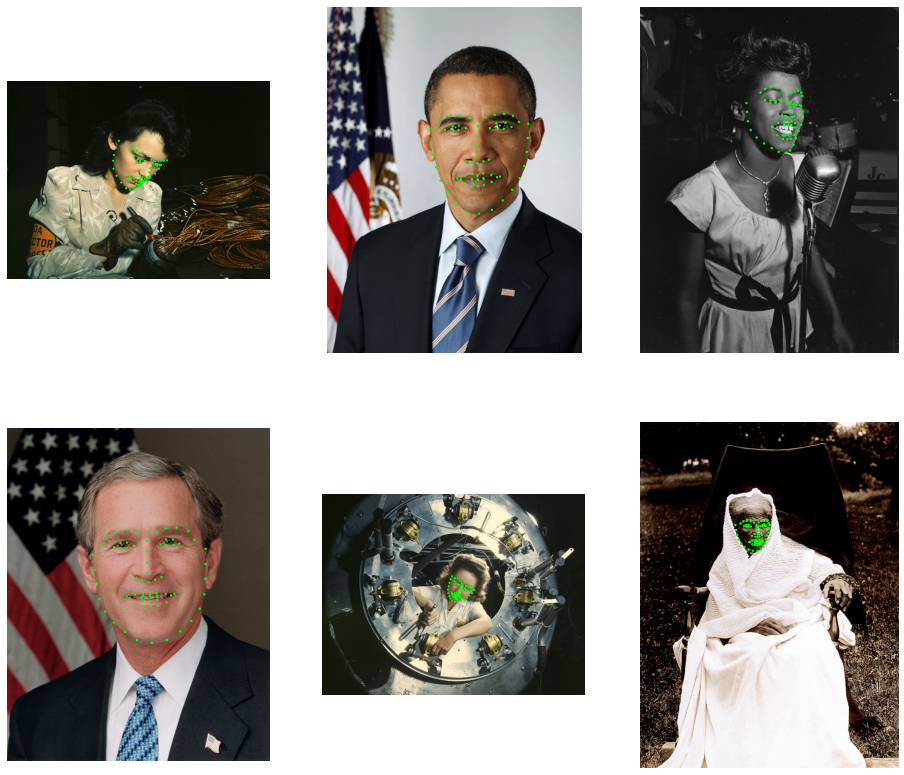

In [5]:
show(images, keypoints)

## Adding Transforms to the Pipeline

In this step we apply a transform to the images and keypoints. We use `warp_affine` to transform images and `coord_transform` to transform keypoints.
The operator `warp_affine` uses the transform matrix to perform inverse mapping: destination pixel coordinates are mapped to source coordinates. This effectively transforms the locations of image features by the inverse of the transform matrix. To make the keypoints and images transformed in the same way, we need to specify `inverse_map=False` in warp_affine.

In [6]:
@pipeline_def
def rotate_pipe():
    jpegs, _ = fn.readers.file(file_root=root_dir, files=image_files)
    images = fn.decoders.image(jpegs, device="mixed")
    keypoints = fn.readers.numpy(file_root=root_dir, files=keypoint_files)
    mt = fn.transforms.rotation(angle=fn.random.uniform(range=(-45, 45)))
    images = fn.warp_affine(images, matrix=mt, fill_value=0, inverse_map=False)
    keypoints = fn.coord_transform(keypoints, MT=mt)
    return images, keypoints


pipe = rotate_pipe(batch_size=6, num_threads=3, device_id=0, seed=1234)
pipe.build()
images, keypoints = pipe.run()

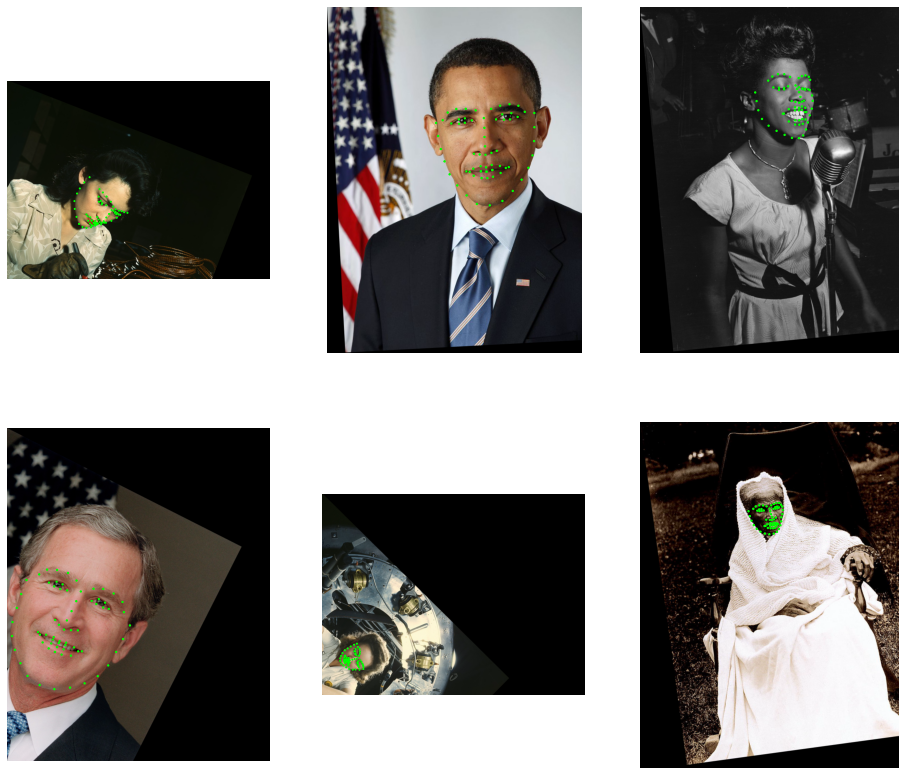

In [7]:
show(images, keypoints)

As we can see, the images have been rotated around point (0, 0) which is top-left corner.
To rotate around the center, we can pass additional `center` argument to rotate.
In order to use the image shapes we must either use the dynamic executor (which allows us to use the shape of a GPU tensor to be used in a CPU operator) or to look up the image shapes before decoding with `peek_image_shape` operator.

In [8]:
@pipeline_def
def center_rotate_pipe():
    jpegs, _ = fn.readers.file(file_root=root_dir, files=image_files)
    images = fn.decoders.image(jpegs, device="mixed")

    # look up the shape of the encoded images and convert them from HWC to WH
    size = fn.peek_image_shape(jpegs)[1::-1]
    center = size / 2

    keypoints = fn.readers.numpy(file_root=root_dir, files=keypoint_files)
    mt = fn.transforms.rotation(
        angle=fn.random.uniform(range=(-45, 45)), center=center
    )
    images = fn.warp_affine(images, matrix=mt, fill_value=0, inverse_map=False)
    keypoints = fn.coord_transform(keypoints, MT=mt)
    return images, keypoints


pipe = center_rotate_pipe(batch_size=6, num_threads=3, device_id=0, seed=1234)
pipe.build()
images, keypoints = pipe.run()

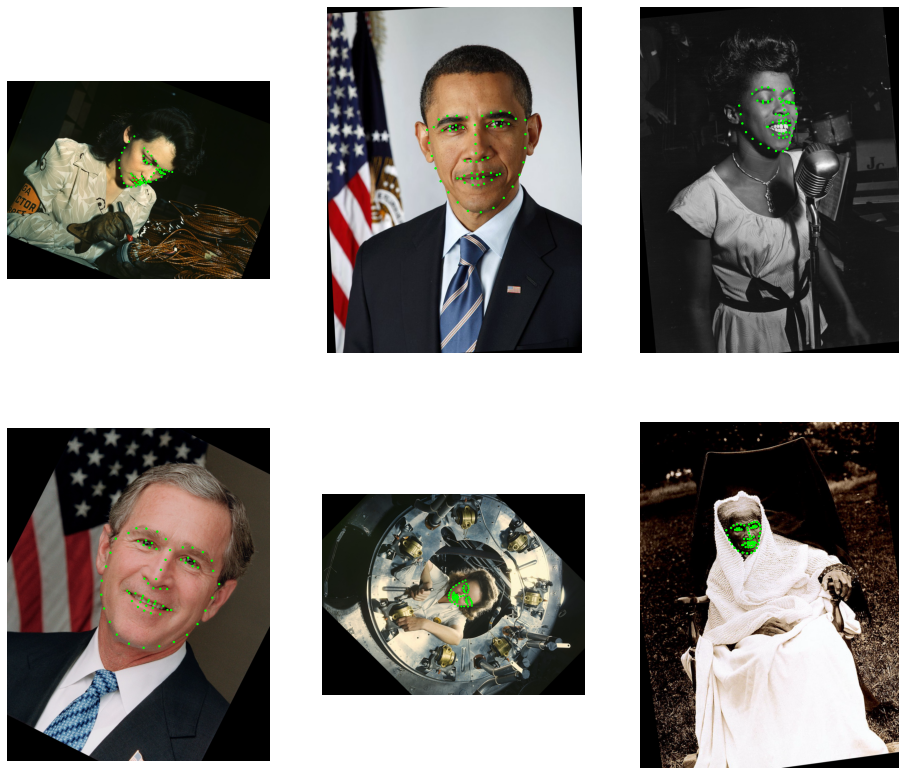

In [9]:
show(images, keypoints)

## Combining Transforms

We can also combine multiple transforms. This can be achieved in two ways:
1. by passing an existing transform matrix as an input to a transform operator,
2. by explicitly using `transforms.combine`

In the example below, we apply rotation followed by a horizontal translation.

In [10]:
@pipeline_def(exec_dynamic=True)
def multi_transform_pipe():
    jpegs, _ = fn.readers.file(file_root=root_dir, files=image_files)
    images = fn.decoders.image(jpegs, device="mixed")

    # with exec_dynamic=True, we can just use the images' shape directly
    size = images.shape()[1::-1]  # get WH from HWC shape
    center = size / 2

    keypoints = fn.readers.numpy(file_root=root_dir, files=keypoint_files)
    mt = fn.transforms.rotation(
        angle=fn.random.uniform(range=(-45, 45)), center=center
    )
    mt = fn.transforms.translation(mt, offset=(300, 0))
    images = fn.warp_affine(images, matrix=mt, fill_value=0, inverse_map=False)
    keypoints = fn.coord_transform(keypoints, MT=mt)
    return images, keypoints


pipe = multi_transform_pipe(batch_size=6, num_threads=3, device_id=0, seed=1234)
pipe.build()
images, keypoints = pipe.run()

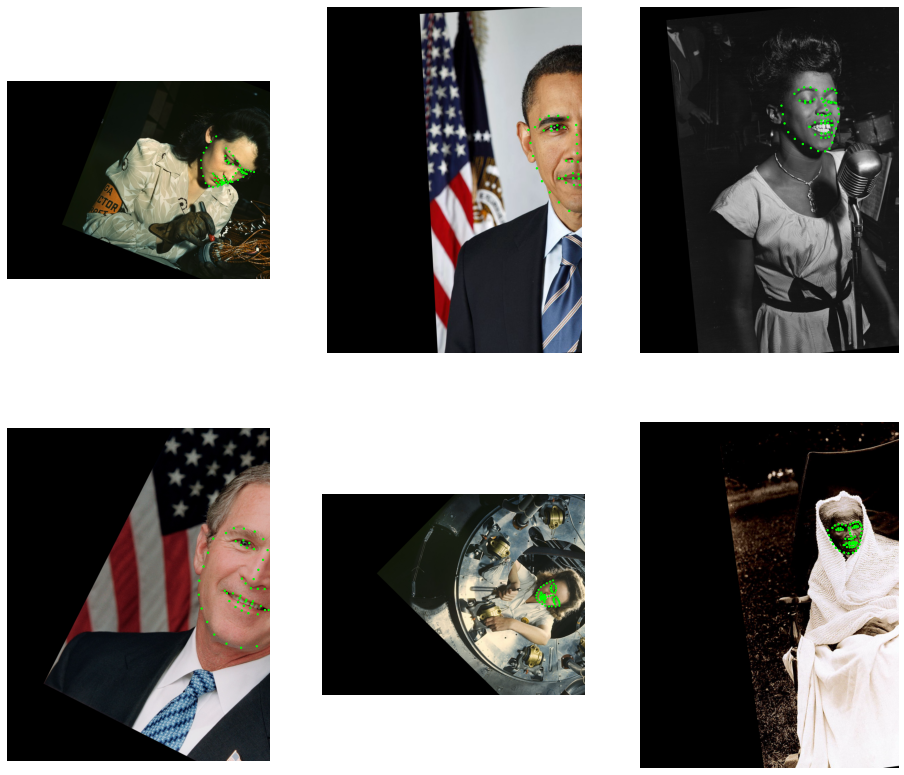

In [11]:
show(images, keypoints)

### Combinining Multiple Transforms with `transforms.combine`

This section demonstrates the usage of `combine` operator with results of other transforms and constants.

In [12]:
@pipeline_def(exec_dynamic=True)
def transform_combine_pipe():
    jpegs, _ = fn.readers.file(file_root=root_dir, files=image_files)
    images = fn.decoders.image(jpegs, device="mixed")

    size = images.shape()[1::-1]  # get WH from HWC shape
    center = size / 2

    keypoints = fn.readers.numpy(file_root=root_dir, files=keypoint_files)
    tr1 = fn.transforms.translation(offset=-center)
    tr2 = fn.transforms.translation(offset=center)
    rot = fn.transforms.rotation(angle=fn.random.uniform(range=(-45, 45)))
    mt = fn.transforms.combine(
        tr1, rot, np.float32([[1, 1, 0], [0, 1, 0]]), tr2
    )
    images = fn.warp_affine(images, matrix=mt, fill_value=0, inverse_map=False)
    keypoints = fn.coord_transform(keypoints, MT=mt)
    return images, keypoints


pipe = transform_combine_pipe(
    batch_size=6, num_threads=3, device_id=0, seed=1234
)
pipe.build()
images, keypoints = pipe.run()

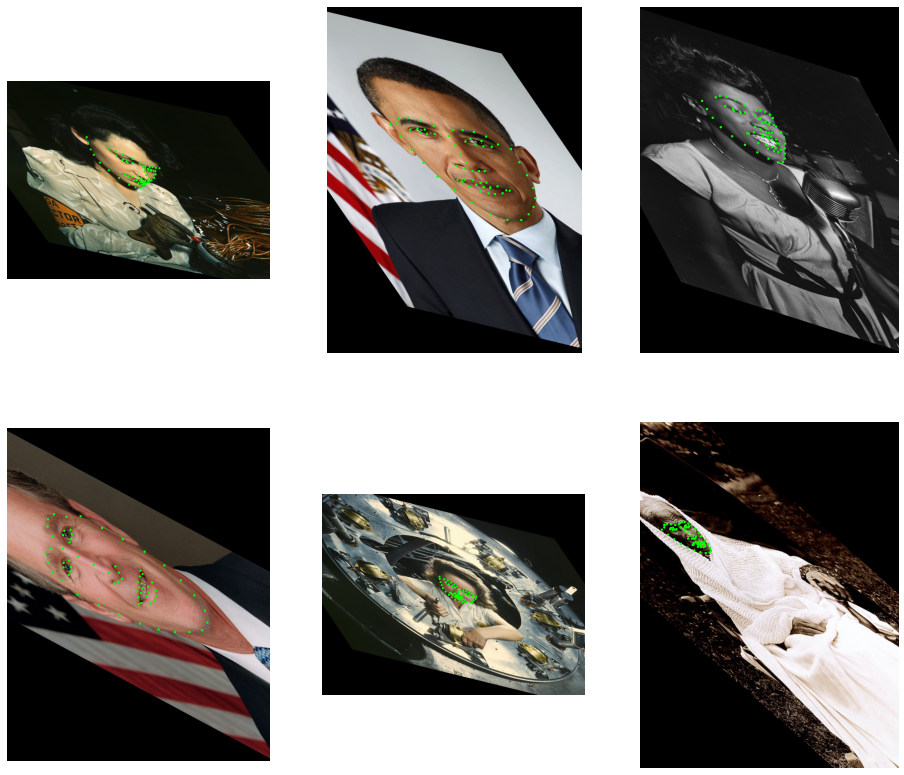

In [13]:
show(images, keypoints)

## Keypoint Cropping

In the example below, we apply some randomized transforms and crop the result so that the face is in the center of the output image.

In [14]:
@pipeline_def
def crop_pipe():
    jpegs, _ = fn.readers.file(file_root=root_dir, files=image_files)
    images = fn.decoders.image(jpegs, device="mixed")
    keypoints = fn.readers.numpy(file_root=root_dir, files=keypoint_files)

    # This part defines the agumentations: shear + rotation
    mt = fn.transforms.shear(shear=fn.random.uniform(range=(-1, 1), shape=[2]))
    mt = fn.transforms.rotation(mt, angle=fn.random.uniform(range=(-45, 45)))

    # Now, let's see where the keypoints would be after applying this transform
    uncropped = fn.coord_transform(keypoints, MT=mt)

    # Find the bounding box of the keypoints
    lo = fn.reductions.min(uncropped, axes=[0])
    hi = fn.reductions.max(uncropped, axes=[0])
    # ...and get its larger extent (width or height)
    size = fn.reductions.max(hi - lo)
    center = (lo + hi) / 2
    # make a square region centered at the center of the bounding box
    lo = center - size  # full size - this adds 50% margin
    hi = center + size  # likewise

    # Now we can calculate a crop transform that will map the bounding box to
    # a 400x400 window and combine it with the previous transform.
    mt = fn.transforms.crop(
        mt, from_start=lo, from_end=hi, to_start=[0, 0], to_end=[400, 400]
    )

    # Apply the transform to the keypoints; specify the output size of 400x400.
    images = fn.warp_affine(
        images, size=[400, 400], matrix=mt, fill_value=0, inverse_map=False
    )
    keypoints = fn.coord_transform(keypoints, MT=mt)
    return images, keypoints


pipe = crop_pipe(batch_size=6, num_threads=3, device_id=0, seed=1234)
pipe.build()
images, keypoints = pipe.run()

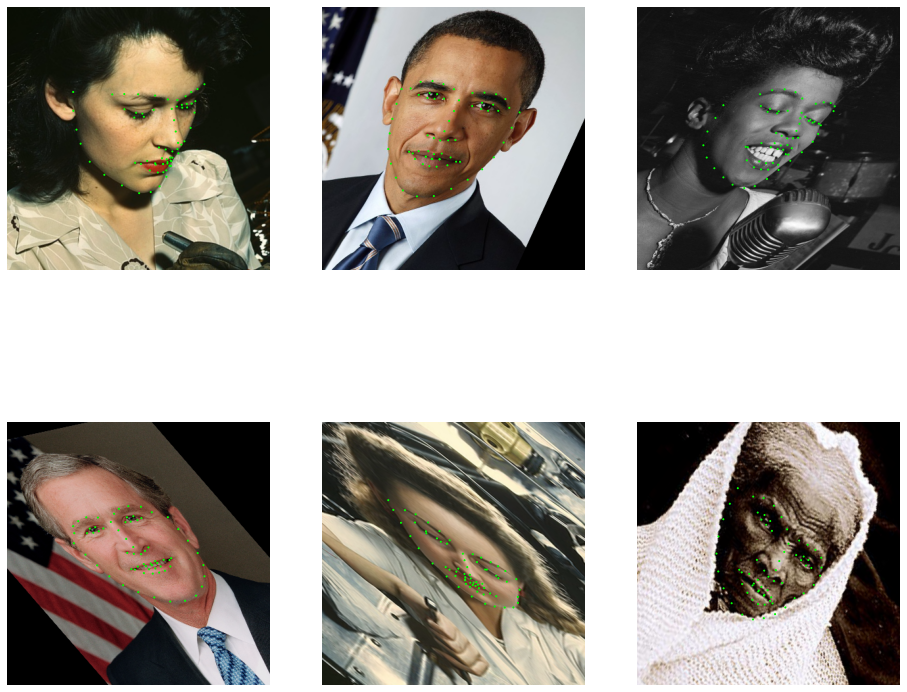

In [15]:
show(images, keypoints)

## Transform Gallery

This section demonstrates each of the transforms applied to all of the example images.

In [16]:
@pipeline_def(exec_dynamic=True)
def transforms_gallery_pipe():
    jpegs, _ = fn.readers.file(file_root=root_dir, files=image_files)
    images = fn.decoders.image(jpegs, device="mixed")
    keypoints = fn.readers.numpy(file_root=root_dir, files=keypoint_files)

    size = images.shape()[1::-1]
    center = size / 2

    outputs = []

    transforms = [
        fn.transforms.translation(
            offset=fn.random.uniform(range=(-100, 100), shape=2)
        ),
        fn.transforms.rotation(
            angle=fn.random.uniform(range=(-45, 45)), center=center
        ),
        fn.transforms.scale(
            scale=fn.random.uniform(range=(0.5, 2), shape=[2]), center=center
        ),
        fn.transforms.shear(
            shear=fn.random.uniform(range=(-1, 1), shape=[2]), center=center
        ),
        fn.transforms.crop(
            from_start=size * 0.1,
            from_end=size * 0.8,
            to_start=[0, 0],
            to_end=size * 1.0,
        ),
    ]

    for mt in transforms:
        out_img = fn.warp_affine(
            images, matrix=mt, fill_value=0, inverse_map=False
        )
        out_kp = fn.coord_transform(keypoints, MT=mt)
        outputs += [out_img, out_kp]
    return tuple(outputs)


pipe = transforms_gallery_pipe(
    batch_size=6, num_threads=3, device_id=0, seed=1234
)
pipe.build()
pipe_out = pipe.run()

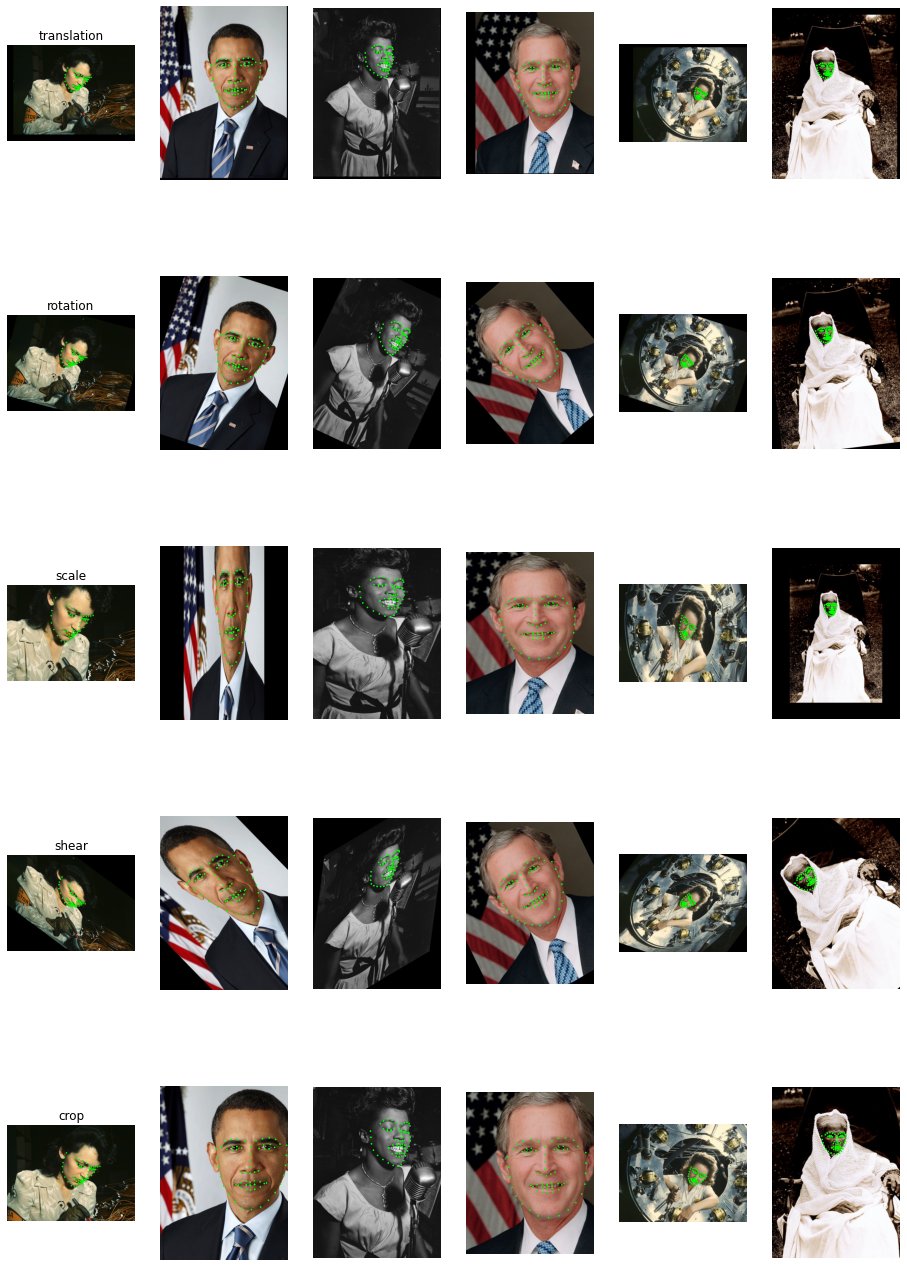

In [17]:
def gallery(pipe_out, titles):
    pipe_out = [x.as_cpu() if hasattr(x, "as_cpu") else x for x in pipe_out]

    batch_size = len(pipe_out[0])

    import matplotlib.gridspec as gridspec

    fig = plt.figure(figsize=(16, 24))
    plt.suptitle(None)
    columns = batch_size
    rows = len(pipe_out) // 2
    gs = gridspec.GridSpec(rows, columns)
    flat = 0
    for j in range(0, len(pipe_out), 2):
        for i in range(batch_size):
            ax = plt.subplot(gs[flat])
            plt.axis("off")
            plt.title("")
            img = pipe_out[j].at(i)
            r = 0.002 * max(img.shape[0], img.shape[1])
            for p in pipe_out[j + 1].at(i):
                circle = patches.Circle(p, r, color=(0, 1, 0, 1))
                ax.add_patch(circle)
            plt.imshow(img)
            if i == 0:
                plt.title(titles[j // 2])
            flat += 1


gallery(pipe_out, ["translation", "rotation", "scale", "shear", "crop"])